# E-Commerce Sales Analytics


This notebook aims to perfom analytic calculations on the dataset from [Kaggle](https://www.kaggle.com/datasets/fahmidachowdhury/e-commerce-sales-analysis).

The aim is to answer the following questions:
- Which categories drive the most revenue and units?
- Do high-rated ategories also sell the most?
- Are there seasonal trends across the 12 months?
- How concentrated is revenue among top products?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading and Inspection

In [5]:
df = pd.read_csv("../data/ecommerce_sales_analysis.csv")
pd.set_option("display.float_format", "{:,.2f}".format)
print(df.head())
print(df.shape)
print(df.info())

   product_id product_name        category  price  review_score  review_count  \
0           1    Product_1        Clothing 190.40          1.70           220   
1           2    Product_2  Home & Kitchen 475.60          3.20           903   
2           3    Product_3            Toys 367.34          4.50           163   
3           4    Product_4            Toys 301.34          3.90           951   
4           5    Product_5           Books  82.23          4.20           220   

   sales_month_1  sales_month_2  sales_month_3  sales_month_4  sales_month_5  \
0            479            449             92            784            604   
1             21            989            861            863            524   
2            348            558            567            143            771   
3            725            678             59             15            937   
4            682            451            649            301            620   

   sales_month_6  sales_month_7 

## Data Cleaning and Validation

In [6]:
# Missing values
print("Missing values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Basic statistics
print("\nSummary statistics:")
print(df.describe())

Missing values:
product_id        0
product_name      0
category          0
price             0
review_score      0
review_count      0
sales_month_1     0
sales_month_2     0
sales_month_3     0
sales_month_4     0
sales_month_5     0
sales_month_6     0
sales_month_7     0
sales_month_8     0
sales_month_9     0
sales_month_10    0
sales_month_11    0
sales_month_12    0
dtype: int64

Duplicate rows: 0

Summary statistics:
       product_id    price  review_score  review_count  sales_month_1  \
count    1,000.00 1,000.00      1,000.00      1,000.00       1,000.00   
mean       500.50   247.68          3.03        526.51         498.31   
std        288.82   144.61          1.17        282.27         289.94   
min          1.00     7.29          1.00          1.00           0.00   
25%        250.75   121.81          2.00        283.75         245.50   
50%        500.50   250.92          3.10        543.00         507.50   
75%        750.25   373.44          4.00        772.00      

## Reshaping to long format

The raw data is wide, meaning there is one row per product with 12 monthly sales columns. For time-aware analysis we melt the dataframe into long format. In this format there is one row per product per month. This makes month-based grouping and trend analysis possible.

In [7]:
month_cols = [c for c in df.columns if c.startswith('sales_month_')]

long_df = df.melt(
    id_vars=['product_id', 'product_name', 'category', 'price', 'review_score', 'review_count'],
    value_vars=month_cols,
    var_name='month',
    value_name='units_sold'
)
print(long_df.head())

   product_id product_name        category  price  review_score  review_count  \
0           1    Product_1        Clothing 190.40          1.70           220   
1           2    Product_2  Home & Kitchen 475.60          3.20           903   
2           3    Product_3            Toys 367.34          4.50           163   
3           4    Product_4            Toys 301.34          3.90           951   
4           5    Product_5           Books  82.23          4.20           220   

           month  units_sold  
0  sales_month_1         479  
1  sales_month_1          21  
2  sales_month_1         348  
3  sales_month_1         725  
4  sales_month_1         682  


## Category-Level Performance
Given the data of sales across a year, we can derive which product categories should the retailer prioritize for investment, and which might be underperforming despite appearances.

This section explores category-level revenue, total sales and customer sentiment to produce a defensible ranking of categories by overall business performance.

First, we build a product-level summary for easier analysis.

In [8]:
long_df['revenue'] = long_df['units_sold'] * long_df['price']

# product level summary
product_summary = (
    long_df.groupby("product_id")
      .agg(
          product_name=("product_name", "first"),
          category=("category", "first"),
          price=("price", "first"),
          review_score=("review_score", "first"),
          review_count=("review_count", "first"),
          total_sales=("units_sold", "sum"),
          total_revenue=("revenue", "sum"),
      )
      .reset_index()
)

product_summary["avg_monthly_sales"] = (
    product_summary["total_sales"] / 12
)

print(product_summary.head())

   product_id product_name        category  price  review_score  review_count  \
0           1    Product_1        Clothing 190.40          1.70           220   
1           2    Product_2  Home & Kitchen 475.60          3.20           903   
2           3    Product_3            Toys 367.34          4.50           163   
3           4    Product_4            Toys 301.34          3.90           951   
4           5    Product_5           Books  82.23          4.20           220   

   total_sales  total_revenue  avg_monthly_sales  
0         6421   1,222,558.40             535.08  
1         6027   2,866,441.20             502.25  
2         5580   2,049,757.20             465.00  
3         5022   1,513,329.48             418.50  
4         6094     501,109.62             507.83  


### Units Sold
By aggregating product totals by category, we can find out which categories sold the most.

In [9]:
category_sales = (
    product_summary.groupby("category")["total_sales"].sum().sort_values(ascending=False)
)
print(category_sales)

category
Books             938229
Toys              917101
Sports            916371
Electronics       845120
Health            834414
Clothing          826536
Home & Kitchen    742141
Name: total_sales, dtype: int64


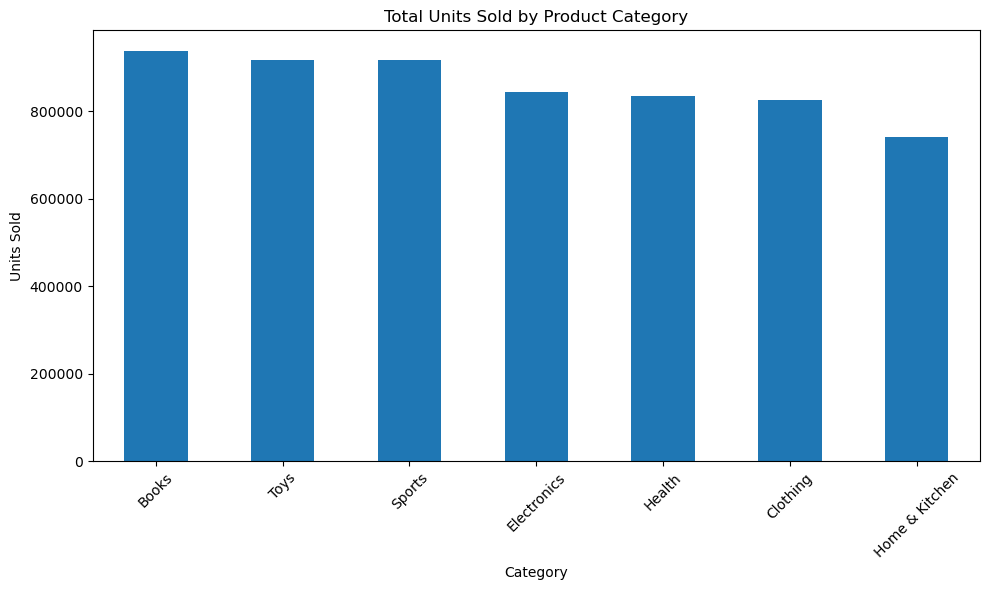

In [10]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Total Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue

In [11]:
category_revenue = (
    product_summary.groupby("category")['total_revenue'].sum().sort_values(ascending=False)
)

print(category_revenue)

category
Books            236,782,805.60
Sports           232,648,831.88
Toys             230,237,183.23
Health           221,736,852.13
Electronics      201,674,684.07
Clothing         187,258,320.85
Home & Kitchen   178,365,505.26
Name: total_revenue, dtype: float64


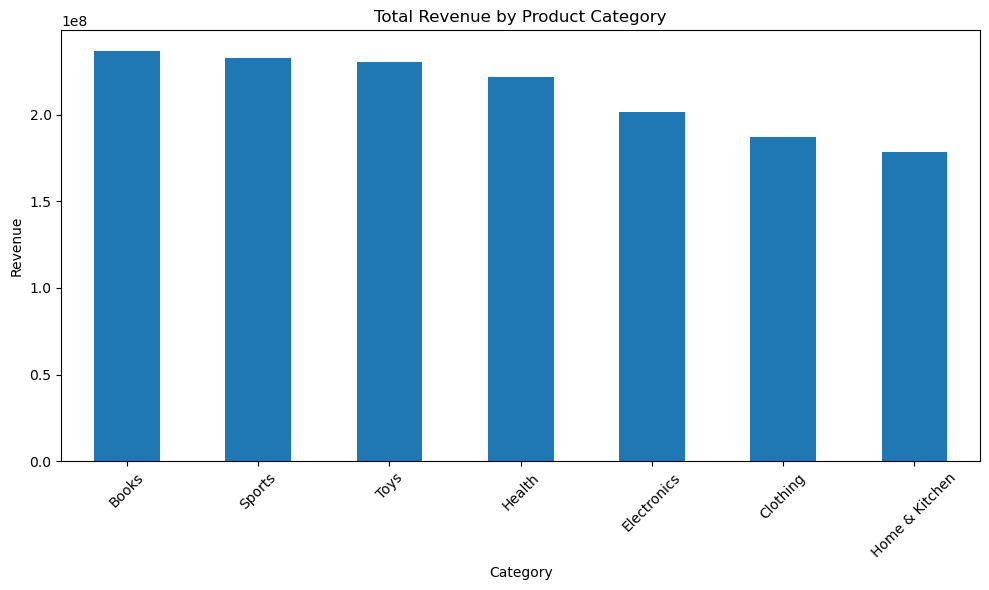

In [12]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
category_summary = (
    product_summary.groupby("category")
      .agg(
          products=("product_id", "nunique"),
          total_sales=("total_sales", "sum"),
          total_revenue=("total_revenue", "sum"),
          avg_price=("price", "mean"),
          avg_rating=("review_score", "mean"),
          total_reviews=("review_count", "sum"),
      )
)

print(category_summary)

                products  total_sales  total_revenue  avg_price  avg_rating  \
category                                                                      
Books                154       938229 236,782,805.60     251.38        3.10   
Clothing             140       826536 187,258,320.85     230.04        2.95   
Electronics          138       845120 201,674,684.07     239.67        3.14   
Health               139       834414 221,736,852.13     265.14        3.01   
Home & Kitchen       125       742141 178,365,505.26     239.77        3.04   
Sports               153       916371 232,648,831.88     254.22        3.09   
Toys                 151       917101 230,237,183.23     251.40        2.87   

                total_reviews  
category                       
Books                   79263  
Clothing                70347  
Electronics             73862  
Health                  72398  
Home & Kitchen          67735  
Sports                  83726  
Toys                    79175  


In [14]:
category_revenue = (
    product_summary.groupby("category")['total_revenue'].sum().sort_values(ascending=False)
)

print(category_revenue)

category
Books            236,782,805.60
Sports           232,648,831.88
Toys             230,237,183.23
Health           221,736,852.13
Electronics      201,674,684.07
Clothing         187,258,320.85
Home & Kitchen   178,365,505.26
Name: total_revenue, dtype: float64


### Customer Sentiment

In [15]:
category_summary["total_revenue"] = category_summary["total_revenue"].round(2)
category_summary["avg_price"] = category_summary["avg_price"].round(2)
category_summary["avg_rating"] = category_summary["avg_rating"].round(2)

category_summary

,products,total_sales,total_revenue,avg_price,avg_rating,total_reviews
category,,,,,,
Books,154,938229,"236,782,805.60",251.38,3.10,79263
Clothing,140,826536,"187,258,320.85",230.04,2.95,70347
Electronics,138,845120,"201,674,684.07",239.67,3.14,73862
Health,139,834414,"221,736,852.13",265.14,3.01,72398
Home & Kitchen,125,742141,"178,365,505.26",239.77,3.04,67735
Sports,153,916371,"232,648,831.88",254.22,3.09,83726
Toys,151,917101,"230,237,183.23",251.40,2.87,79175


As can be concluded from the plot, Books lead on revenue ($236.8M) and also sold the most units (938k). 

## Monthly Trends

### Total Sales per Month
The plot below shows the total sales of all products in each month. 

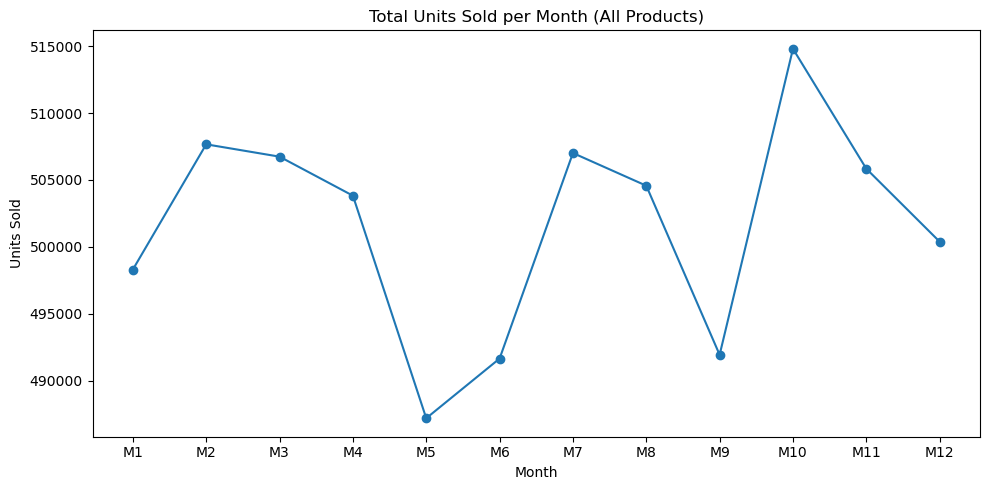

In [16]:
monthly_total = long_df.groupby("month")['units_sold'].sum()
month_order = [f"sales_month_{i}" for i in range(1, 13)]
monthly_total = monthly_total.reindex(month_order)


ax = monthly_total.plot(kind="line", marker="o", figsize=(10, 5))
ax.set_title("Total Units Sold per Month (All Products)")
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")
ax.set_xticks(range(len(monthly_total)))          # explicit tick positions
ax.set_xticklabels([f"M{i}" for i in range(1, 13)])  # 12 labels
plt.tight_layout()
plt.show()

In [17]:
print(monthly_total)

month
sales_month_1     498306
sales_month_2     507661
sales_month_3     506739
sales_month_4     503823
sales_month_5     487194
sales_month_6     491653
sales_month_7     507011
sales_month_8     504569
sales_month_9     491934
sales_month_10    514798
sales_month_11    505838
sales_month_12    500386
Name: units_sold, dtype: int64


### Monthly Trend per Category
In the plot below, the total sales of each category is calculated and compared across 12 months.

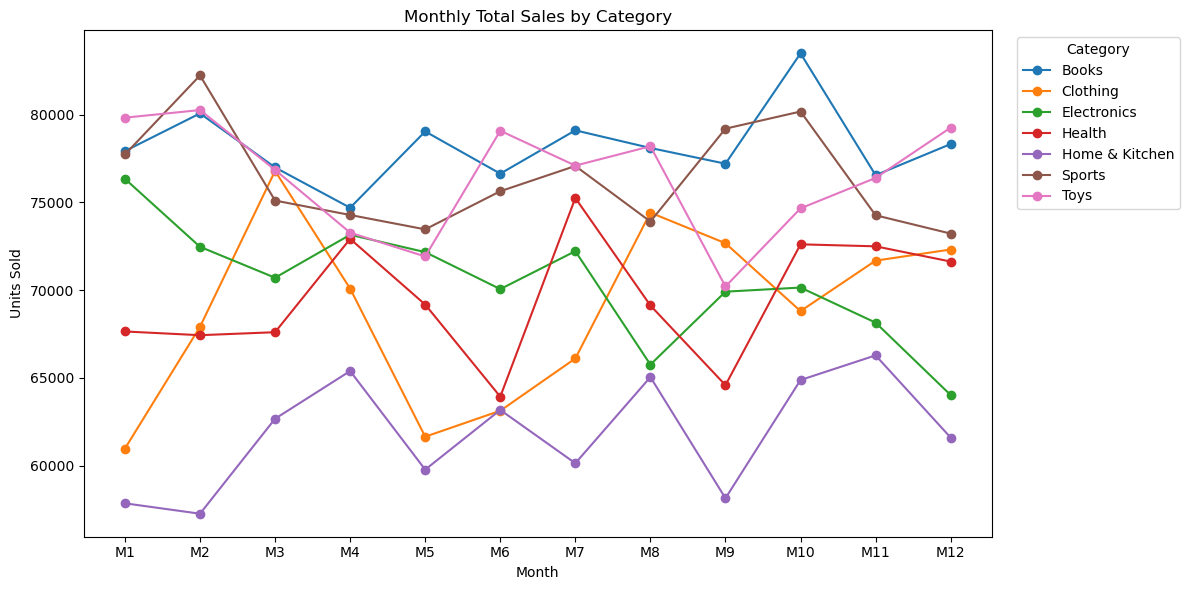

In [18]:
monthly_by_cat = (
    long_df.groupby(['month', 'category'])['units_sold']
    .sum()
    .unstack('category')
)

monthly_by_cat = monthly_by_cat.reindex(month_order)

ax = monthly_by_cat.plot(kind="line", marker="o", figsize=(12, 6))
ax.set_title("Monthly Total Sales by Category")
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")
ax.set_xticks(range(len(monthly_by_cat)))
ax.set_xticklabels([f"M{i}" for i in range(1, 13)])
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
print(monthly_by_cat)

category        Books  Clothing  Electronics  Health  Home & Kitchen  Sports  \
month                                                                          
sales_month_1   77932     60966        76347   67644           57844   77737   
sales_month_2   80079     67911        72472   67432           57252   82244   
sales_month_3   76998     76796        70708   67602           62667   75109   
sales_month_4   74699     70088        73158   72925           65388   74287   
sales_month_5   79051     61643        72169   69178           59766   73467   
sales_month_6   76644     63123        70060   63926           63169   75641   
sales_month_7   79114     66105        72223   75256           60129   77082   
sales_month_8   78108     74422        65754   69126           65042   73912   
sales_month_9   77211     72675        69914   64581           58135   79209   
sales_month_10  83504     68806        70148   72613           64876   80187   
sales_month_11  76557     71683        6

### Month over Month growth rate
Using pct_change(), we calculate the fractional growth of total sales from each month to the next.

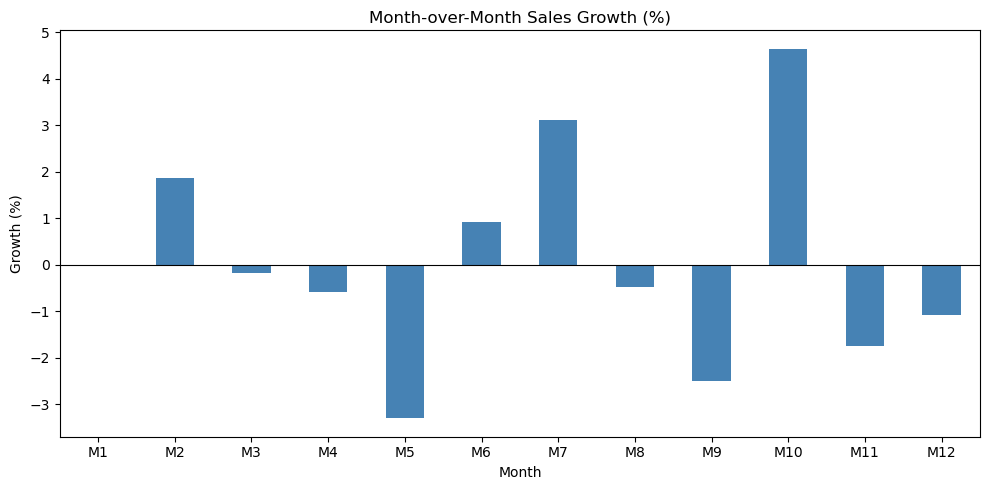

Peak month: sales_month_10 = 514798 units
Lowest month: sales_month_5 = 487194 units


In [20]:
mom_growth = monthly_total.pct_change() * 100

ax = mom_growth.plot(kind="bar", figsize=(10, 5), color="steelblue")
ax.set_title("Month-over-Month Sales Growth (%)")
ax.set_xlabel("Month")
ax.set_ylabel("Growth (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticklabels([f"M{i}" for i in range(1, 13)], rotation=0)
plt.tight_layout()
plt.show()

print("Peak month:", monthly_total.idxmax(), "=", monthly_total.max(), "units")
print("Lowest month:", monthly_total.idxmin(), "=", monthly_total.min(), "units")


### Trend Observation
The following can be concluded:
- Total monthly sales fluctuate rapidly, with a peak in **Month 10** and a trough at **Month 5**
- All categories experince extreme variations, with **Books** having the most relative stability throughout the year
- Month over Month growth stays within a narrow band of ±5%, oscillating around zero with no sustained upward or downward trend. The largest movements are a +4.7% jump in **Month 10** and a -3.2% dip in **Month 5**, but neither is followed by continued momentum. This pattern is consistent with the dataset being synthetically generated rahter than reflecting real seasonal demand.

## Statistical & Relational Analysis


### Correlation Matrix

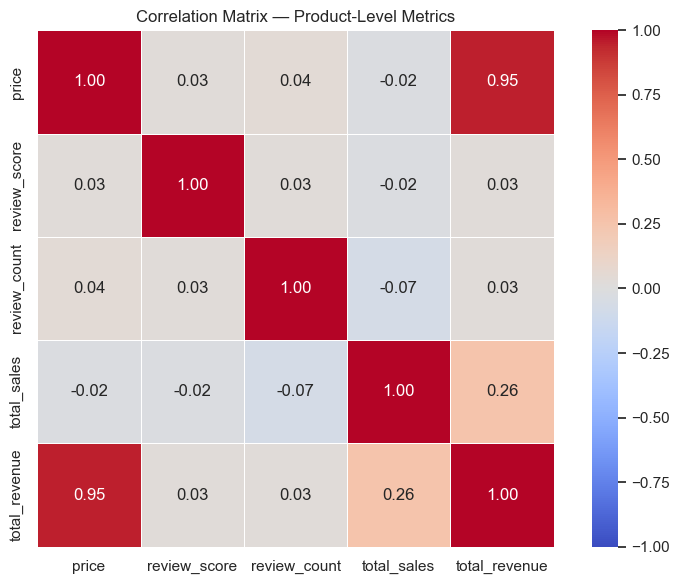

In [21]:
sns.set_theme(style="whitegrid")

num_cols = ['price', 'review_score', 'review_count', 'total_sales', 'total_revenue']
corr = product_summary[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Product-Level Metrics")
plt.tight_layout()
plt.show()

Key take aways from the correlation matrix:
- The correlation between Price and total revenue is very high (0.95), which is arithmetically expected since revenue = price * units_sold. 
- Unlike real case datasets where price and quantity are typically negatively correlated, here they seem independent of each other. This means, price has no measurable influence on the units sold.

**The absence of expected relationships is due to the dataset being synthetically generated.**

### Price vs. Sales
This section visualizes the relationship between two continuous variables. Complementing the correlation number with shape and outliers.

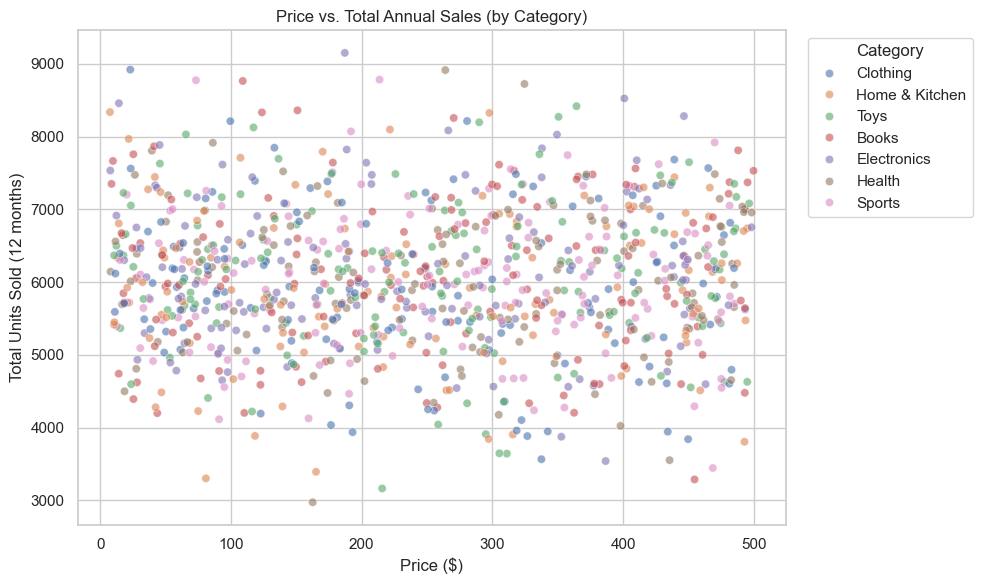

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=product_summary, x="price", y="total_sales",
                hue="category", alpha=0.6, ax=ax)
ax.set_title("Price vs. Total Annual Sales (by Category)")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Total Units Sold (12 months)")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The scatter confirms the near-zero correlation coefficient as there are no visible relationship between price and total annual sales. 

Category coloring also revelas no segmentation by price. products across all
seven categories are scattered throughout the price and sales ranges. In real
e-commerce, we would expect either (a) a downward slope reflecting price
sensitivity, or (b) category-level clustering if certain categories occupied
specific price bands. Neither pattern is present.

### Rating Distribution by Category
Using Boxplot, we display the distribution of review scores within each category. 

C:\Users\Asus\AppData\Local\Temp\ipykernel_11440\1085319687.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=product_summary, x="category", y="review_score",


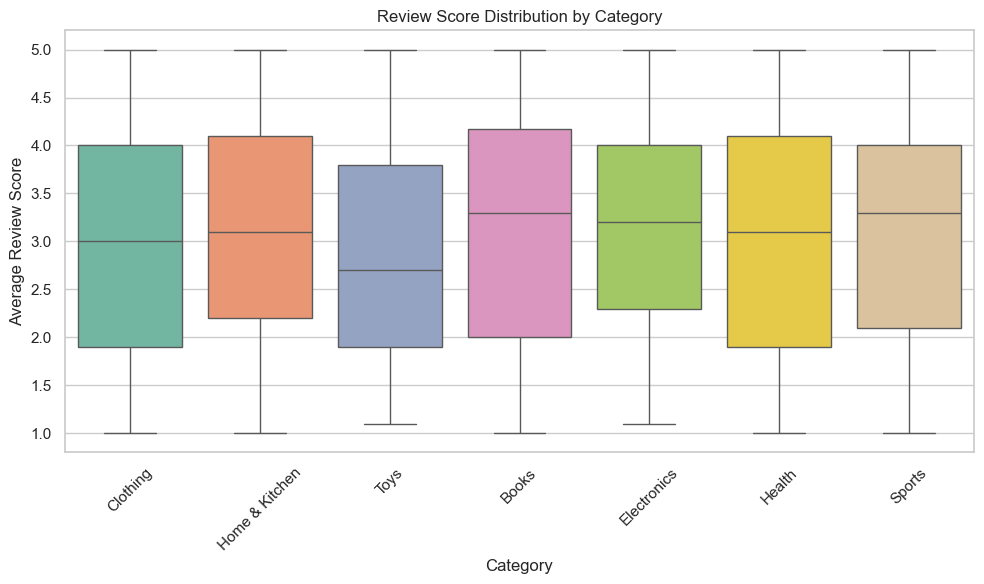

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=product_summary, x="category", y="review_score",
            palette="Set2", ax=ax)
ax.set_title("Review Score Distribution by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Boplots show the distribution of average review scores within each of the seven product categories. Three patterns stand out:
- **Wide within-category spread.** Every category spans nearly the full
   1.0–5.0 range, with an interquartile range (IQR) of roughly 2 points and
   the middle 50% of products covers 40% of the rating scale. There are no
   tight, homogeneous categories.
- **Similar medians.** Median scores cluster tightly between 2.7 (Toys)
   and 3.2 (Books) with a spread of just 0.5 points. The visual difference
   between the boxes is small relative to their internal variance.
- **No outliers.** Every category has whiskers reaching ~1.0 and ~5.0 with
   no points beyond, which is consistent with uniformly-distributed data, where extreme values are common and not statistically anomalous.

The Uniform distributions across all categories confirm synthetic generation and mean any category-level rating comparison would be statistically meaningless.


## Revenue Concentration (Pareto)
This section answers the question "What fraction of products drive 80% of revenue?" as according to the Pareto Principle. 

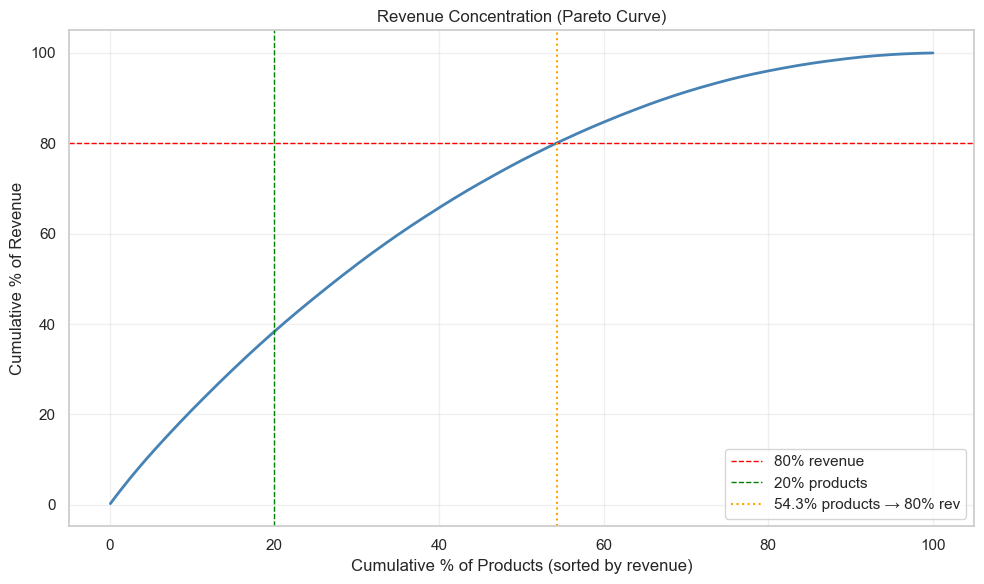

Top 54.3% of products drive 80% of revenue.


In [25]:
sorted_rev = product_summary.sort_values('total_revenue', ascending=False)['total_revenue'].reset_index(drop=True)

# Cummulative percentage of revenue
cummulative_rev_pct = sorted_rev.cumsum() / sorted_rev.sum() * 100

# Cummulative percentage of products
product_pct = (sorted_rev.index + 1) / len(sorted_rev) * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(product_pct, cummulative_rev_pct, color="steelblue", linewidth=2)
ax1.axhline(80, color="red", linestyle="--", linewidth=1, label="80% revenue")
ax1.axvline(20, color="green", linestyle="--", linewidth=1, label="20% products")

# Find the x-value where cumulative revenue hits 80%
idx_80 = next(i for i, v in enumerate(cummulative_rev_pct) if v >= 80)
pct_products_for_80 = (idx_80 + 1) / len(sorted_rev) * 100
ax1.axvline(pct_products_for_80, color="orange", linestyle=":",
            label=f"{pct_products_for_80:.1f}% products → 80% rev")

ax1.set_title("Revenue Concentration (Pareto Curve)")
ax1.set_xlabel("Cumulative % of Products (sorted by revenue)")
ax1.set_ylabel("Cumulative % of Revenue")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top {pct_products_for_80:.1f}% of products drive 80% of revenue.")

The Pareto curve describes how cummulative revenue accumulates as we add products in descending order of revenue. The observed patters are as such:
- 20% of products bring 38% of revenue
- 50% of products bring 75% of revenue
- 54.3% of products bring 38% of revenue

The curve shows that revenue is uniformly distributed across products, with no concentration.
